In [11]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time


# ESN FUNCTIONS
def generate_esn(n_inputs, n_reservoir, spectral_radius=0.9, input_scaling=1.0, bias_scaling=1.0, connectivity=1.0, seed=42,):
    
    rng = np.random.default_rng(seed)

    Win = rng.uniform(low=-0.5 * input_scaling, high=0.5 * input_scaling, size=(n_reservoir, n_inputs))
    Wbias = rng.uniform(low=-0.5 * bias_scaling, high=0.5 * bias_scaling, size=(n_reservoir, 1))
    W = rng.uniform(low=-0.5, high=0.5, size=(n_reservoir, n_reservoir))

    # Sparsify if needed
    if connectivity < 1.0:
        mask = rng.random((n_reservoir, n_reservoir)) < connectivity
        W *= mask

    # Scale to desired spectral radius
    eigvals = np.linalg.eigvals(W)
    rho = np.max(np.abs(eigvals))
    W *= spectral_radius / rho

    return Win, W, Wbias


def esn_step(x, u, Win, W, Wbias, leak_rate):
    preactivation = Win @ u + W @ x + Wbias
    x_new = (1.0 - leak_rate) * x + leak_rate * np.tanh(preactivation)
    return x_new


def fit_esn(X_train, Y_train, Win, W, Wbias, leak_rate=1.0, washout=100, ridge=1e-8):
    """
    Train readout using ridge regression.

    X_train: (T, n_inputs)
    Y_train: (T, n_outputs)
    """
    T = X_train.shape[0]
    n_res = W.shape[0]
    n_inputs = X_train.shape[1]

    x = np.zeros((n_res, 1))

    X_collect = []
    Y_collect = []

    for t in range(T):
        u = X_train[t].reshape(n_inputs, 1)
        x = esn_step(x, u, Win, W, Wbias, leak_rate)

        if t >= washout:
            extended_state = np.vstack([np.ones((1, 1)), u, x])[:, 0]
            X_collect.append(extended_state)
            Y_collect.append(Y_train[t])

    X_design = np.array(X_collect).T
    Y_target = np.array(Y_collect).T

    A = X_design @ X_design.T + ridge * np.eye(X_design.shape[0])
    B = Y_target @ X_design.T

    # Equivalent to ridge regression formula, but numerically a bit cleaner
    Wout = np.linalg.solve(A.T, B.T).T

    return Wout


def run_esn_open_loop(X_seq, Win, W, Wbias, Wout=None, leak_rate=1.0, x0=None):
    """
    Run ESN using true inputs.
    Returns final state, and optionally outputs.
    """
    T = X_seq.shape[0]
    n_res = W.shape[0]
    n_inputs = X_seq.shape[1]

    x = np.zeros((n_res, 1)) if x0 is None else x0.copy()

    states = []
    outputs = []

    for t in range(T):
        u = X_seq[t].reshape(n_inputs, 1)
        x = esn_step(x, u, Win, W, Wbias, leak_rate)
        states.append(x[:, 0].copy())

        if Wout is not None:
            extended_state = np.vstack([np.ones((1, 1)), u, x])
            y = Wout @ extended_state
            outputs.append(y[:, 0].copy())

    states = np.array(states)

    if Wout is not None:
        outputs = np.array(outputs)
        return states, outputs, x

    return states, x


def predict_closed_loop(initial_input, steps, Win, W, Wbias, Wout, leak_rate=1.0, x0=None):
    """
    Closed-loop prediction:
    predicted output becomes next input.
    """
    n_res = W.shape[0]
    n_inputs = Win.shape[1]

    x = np.zeros((n_res, 1)) if x0 is None else x0.copy()
    u = np.asarray(initial_input).reshape(n_inputs, 1)

    Y_pred = []

    for _ in range(steps):
        x = esn_step(x, u, Win, W, Wbias, leak_rate)

        extended_state = np.vstack([np.ones((1, 1)), u, x])
        y = Wout @ extended_state
        Y_pred.append(y[:, 0].copy())

        u = y.reshape(n_inputs, 1)

    return np.array(Y_pred), x


def compute_nrmse(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return rmse / (np.std(y_true) + eps)

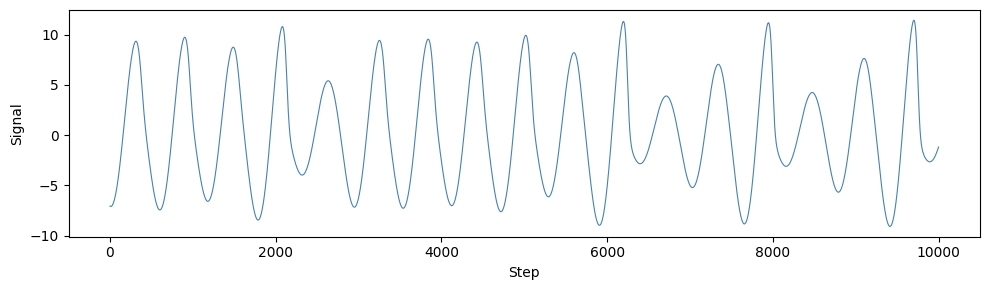

In [12]:
# LOAD DATA
# data should be a 1D numpy array
dataset = np.loadtxt('../data/chaotic_data/rossler_system.csv', delimiter=',')
dataset = dataset[: ,0]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

Total combinations to evaluate: 960
[20/960]  elapsed: 3s  current best NRMSE: 0.037653
[40/960]  elapsed: 7s  current best NRMSE: 0.037653
[60/960]  elapsed: 10s  current best NRMSE: 0.037653
[80/960]  elapsed: 13s  current best NRMSE: 0.024315
[100/960]  elapsed: 16s  current best NRMSE: 0.024315
[120/960]  elapsed: 20s  current best NRMSE: 0.024315
[140/960]  elapsed: 23s  current best NRMSE: 0.024315
[160/960]  elapsed: 26s  current best NRMSE: 0.024315
[180/960]  elapsed: 29s  current best NRMSE: 0.018561
[200/960]  elapsed: 32s  current best NRMSE: 0.018561
[220/960]  elapsed: 35s  current best NRMSE: 0.018561
[240/960]  elapsed: 38s  current best NRMSE: 0.018561
[260/960]  elapsed: 46s  current best NRMSE: 0.018561
[280/960]  elapsed: 54s  current best NRMSE: 0.018561
[300/960]  elapsed: 62s  current best NRMSE: 0.018561
[320/960]  elapsed: 70s  current best NRMSE: 0.018561
[340/960]  elapsed: 78s  current best NRMSE: 0.018561
[360/960]  elapsed: 85s  current best NRMSE: 0.01856

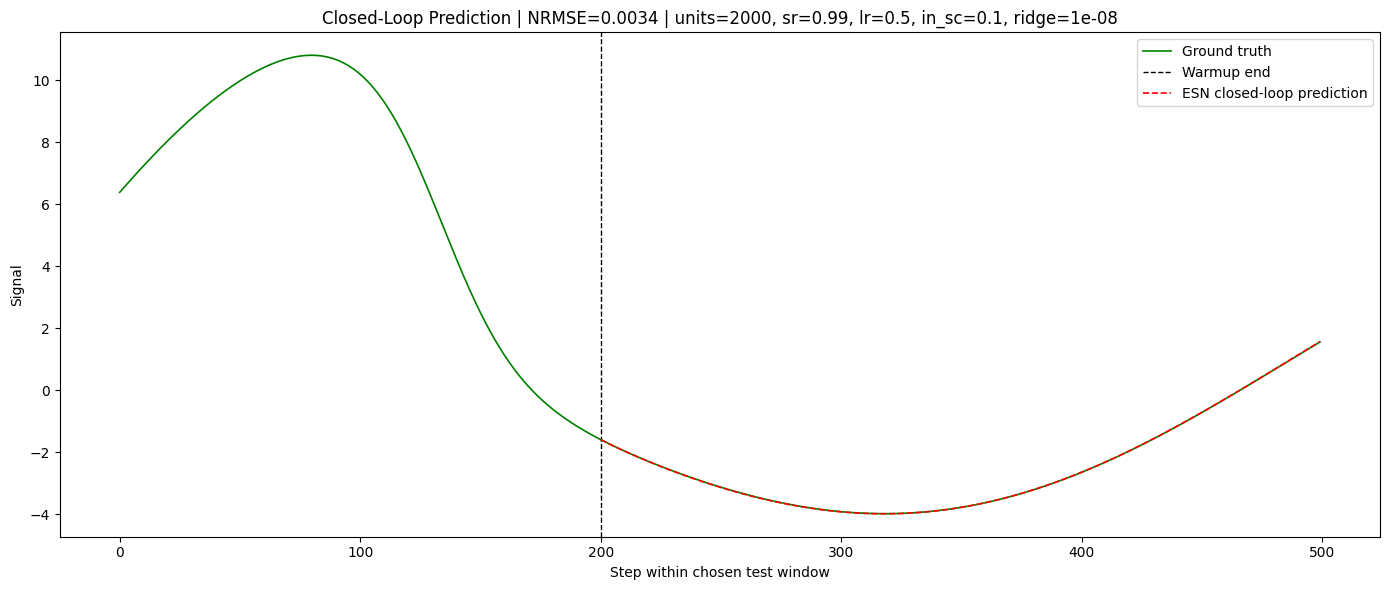

In [9]:
# PREPARE DATA
data = dataset.reshape(-1, 1)
# X[t] = data[t], Y[t] = data[t+1]
X = data[:-1]
Y = data[1:]

# DATA SPLIT SETTINGS
train_len = 2000    # train on [0 : train_len]
train_warmup = 100  # discard first transient states during fit

test_start = 2000   # index where test begins
test_len = 500
warmup_len = 200    # synchronization using true data inside chosen test window

# Training data
X_train = X[:train_len]
Y_train = Y[:train_len]

# Chosen test window
X_test = X[test_start:test_start + test_len]
Y_test = Y[test_start:test_start + test_len]

# Prediction portion is after local test warmup
pred_len = test_len - warmup_len
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]

# DEFINE PARAMETER GRID
param_grid = {
    'units':         [500, 800, 1000, 2000],
    'sr':            [0.95, 0.99, 1.2, 1.3, 1.5],
    'lr':            [0.1, 0.3, 0.5, 1.0],
    'input_scaling': [0.05, 0.1, 0.5, 1.0],
    'ridge':         [1e-8, 1e-6, 1e-4],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))

print(f"Total combinations to evaluate: {len(combos)}")

# EVALUATION FUNCTION
def evaluate_esn(units, sr, lr, input_scaling, ridge, seed=42):
    """
    Build, train, reset, synchronize on chosen test window,
    then run closed-loop prediction and return NRMSE.
    """
    try:
        Win, W, Wbias = generate_esn(
            n_inputs=X_train.shape[1],
            n_reservoir=int(units),
            spectral_radius=sr,
            input_scaling=input_scaling,
            bias_scaling=1.0,
            connectivity=1.0,
            seed=seed,
        )

        Wout = fit_esn(
            X_train=X_train,
            Y_train=Y_train,
            Win=Win,
            W=W,
            Wbias=Wbias,
            leak_rate=lr,
            washout=train_warmup,
            ridge=ridge,
        )

        # Reset before test window
        x_test = np.zeros((int(units), 1))

        # Synchronize on first part of chosen test window: warmup
        if warmup_len > 0:
            _, _, x_test = run_esn_open_loop(
                X_seq=X_test[:warmup_len],
                Win=Win,
                W=W,
                Wbias=Wbias,
                Wout=Wout,
                leak_rate=lr,
                x0=x_test
            )

        # Closed-loop prediction on the rest
        current_input = X_test[warmup_len]
        Y_pred, _ = predict_closed_loop(
            initial_input=current_input,
            steps=pred_len,
            Win=Win,
            W=W,
            Wbias=Wbias,
            Wout=Wout,
            leak_rate=lr,
            x0=x_test
        )

        Y_pred = Y_pred[:, 0]

        # Divergence check
        if np.any(np.isnan(Y_pred)) or np.max(np.abs(Y_pred)) > 1e6:
            return np.inf

        nrmse = compute_nrmse(Y_true, Y_pred)
        return nrmse

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf


# RUN GRID SEARCH
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_esn(**params)
    results.append({**params, 'nrmse': nrmse})

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(
            f"[{i+1}/{len(combos)}]  elapsed: {elapsed:.0f}s  "
            f"current best NRMSE: {best_nrmse:.6f}"
        )

total_time = time.time() - t_start


# RESULTS
print("\n" + "=" * 60)
print("GRID SEARCH COMPLETE")
print(f"Train interval : [0 : {train_len}]")
print(f"Test interval  : [{test_start} : {test_start + test_len}]")
print(f"Warmup length  : {warmup_len}")
print(f"Pred. length   : {pred_len}")
print(f"Total time     : {total_time:.1f}s ({total_time/len(combos):.2f}s per trial)")
print(f"Best NRMSE     : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:20s} = {v}")
print("=" * 60)

# TOP 10 CONFIGURATIONS
results_sorted = sorted(results, key=lambda r: r['nrmse'])

print("\nTop 10 configurations:")
print(f"{'Rank':>4}  {'units':>5}  {'sr':>5}  {'lr':>4}  {'in_sc':>6}  {'ridge':>8}  {'NRMSE':>10}")
print("-" * 62)

for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['units']):5d}  "
        f"{r['sr']:5.2f}  "
        f"{r['lr']:4.1f}  "
        f"{r['input_scaling']:6.2f}  "
        f"{r['ridge']:8.1e}  "
        f"{r['nrmse']:10.6f}"
    )


# VISUALIZE BEST ESN
best_units = int(best_params['units'])
best_sr = best_params['sr']
best_lr = best_params['lr']
best_input_scaling = best_params['input_scaling']
best_ridge = best_params['ridge']

# REBUILD BEST ESN
Win_best, W_best, Wbias_best = generate_esn(
    n_inputs=X_train.shape[1],
    n_reservoir=best_units,
    spectral_radius=best_sr,
    input_scaling=best_input_scaling,
    bias_scaling=1.0,
    connectivity=1.0,
    seed=42,
)

# TRAIN
Wout_best = fit_esn(
    X_train=X_train,
    Y_train=Y_train,
    Win=Win_best,
    W=W_best,
    Wbias=Wbias_best,
    leak_rate=best_lr,
    washout=train_warmup,
    ridge=best_ridge,
)

# TEST
x_best = np.zeros((best_units, 1))

if warmup_len > 0:
    _, _, x_best = run_esn_open_loop(
        X_seq=X_test[:warmup_len],
        Win=Win_best,
        W=W_best,
        Wbias=Wbias_best,
        Wout=Wout_best,
        leak_rate=best_lr,
        x0=x_best
    )

current_input = X_test[warmup_len]
Y_pred_best, _ = predict_closed_loop(
    initial_input=current_input,
    steps=pred_len,
    Win=Win_best,
    W=W_best,
    Wbias=Wbias_best,
    Wout=Wout_best,
    leak_rate=best_lr,
    x0=x_best
)

Y_pred_best = Y_pred_best[:, 0]

# Ground truth aligned
Y_true_best = Y_test[warmup_len:warmup_len + pred_len, 0]

mse = np.mean((Y_true_best - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / (np.std(Y_true_best) + 1e-12)

# Visualize
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test[:, 0], c='green', label="Ground truth", linewidth=1.2)
ax.axvline(warmup_len, linestyle="--", c='k', linewidth=1.0, label="Warmup end")
ax.plot(
    np.arange(warmup_len, warmup_len + pred_len),
    Y_pred_best,
    linestyle="--",
    c='red',
    linewidth=1.2,
    label="ESN closed-loop prediction"
)

ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"units={best_units}, sr={best_sr}, "
    f"lr={best_lr}, in_sc={best_input_scaling}, "
    f"ridge={best_ridge:.0e}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()